In [132]:
from mth5 import mth5
from mth5.utils.helpers import initialize_mth5

from aurora.config import BANDS_DEFAULT_FILE, BANDS_256_29_FILE 
from aurora.config.config_creator import ConfigCreator
from aurora.pipelines.process_mth5 import process_mth5
from mtpy.processing import RunSummary, KernelDataset

from scipy.constants import mu_0
import numpy as np

In [133]:
exp = initialize_mth5('4P_COP24_COO24.h5')

In [134]:
ex = exp.get_channel('COP24', 'b', 'ex', '4P')

In [137]:
mt_exp = exp.to_experiment()

In [151]:
mt_exp.surveys[0].stations["COO24"].runs[0].channels["hy"].measurement_azimuth

98.4

In [143]:
ey

64.3

In [136]:
type(ex)

mth5.groups.channel_dataset.ElectricDataset

In [131]:
cop24 = exp.get_station('COP24', '4P')
cop24.metadata

{
    "station": {
        "acquired_by.name": null,
        "channels_recorded": [
            "ex",
            "ey",
            "hx",
            "hy",
            "hz"
        ],
        "data_type": "MT",
        "fdsn.id": "COP24",
        "geographic_name": "Tiny Town, CO, USA",
        "hdf5_reference": "<HDF5 object reference>",
        "id": "COP24",
        "location.declination.comments": "igrf.m by Drew Compston",
        "location.declination.model": "IGRF-13",
        "location.declination.value": 8.28165279057217,
        "location.elevation": 2243.437133789,
        "location.latitude": 39.606023,
        "location.longitude": -105.2102,
        "mth5_type": "Station",
        "orientation.method": "compass",
        "orientation.reference_frame": "geographic",
        "provenance.archive.name": null,
        "provenance.creation_time": "1980-01-01T00:00:00+00:00",
        "provenance.creator.name": null,
        "provenance.software.author": "Anna Kelbert, USGS",
   

In [8]:
exp_run_summary = RunSummary()
exp_run_summary.from_mth5s([exp])

In [11]:
exp_run_summary.mini_summary

,survey,station,run,start,end,duration
0,4P,COO24,a,2018-09-12 00:25:42+00:00,2018-09-12 01:03:39+00:00,2277.0
1,4P,COO24,b,2018-09-12 01:13:45+00:00,2018-09-12 15:28:40+00:00,51295.0
2,4P,COO24,c,2018-09-12 15:39:54+00:00,2018-09-25 19:26:45+00:00,1136811.0
3,4P,COO24,d,2018-09-27 22:54:38+00:00,2018-10-01 22:40:25+00:00,344747.0
4,4P,COP24,a,2018-09-13 14:32:06+00:00,2018-09-13 15:02:25+00:00,1819.0
5,4P,COP24,b,2018-09-13 15:14:30+00:00,2018-10-01 06:27:33+00:00,1523583.0


In [14]:
kernel_dataset = KernelDataset()
kernel_dataset.from_run_summary(exp_run_summary, "COP24", "COO24")

25:02:06T10:15:12 | INFO | line:262 |mtpy.processing.kernel_dataset | _add_columns | KernelDataset DataFrame needs column fc, adding and setting dtype to <class 'pandas._libs.missing.NAType'>.
25:02:06T10:15:12 | INFO | line:262 |mtpy.processing.kernel_dataset | _add_columns | KernelDataset DataFrame needs column remote, adding and setting dtype to <class 'bool'>.
25:02:06T10:15:12 | INFO | line:262 |mtpy.processing.kernel_dataset | _add_columns | KernelDataset DataFrame needs column run_dataarray, adding and setting dtype to <class 'NoneType'>.
25:02:06T10:15:12 | INFO | line:262 |mtpy.processing.kernel_dataset | _add_columns | KernelDataset DataFrame needs column stft, adding and setting dtype to <class 'NoneType'>.
25:02:06T10:15:12 | INFO | line:262 |mtpy.processing.kernel_dataset | _add_columns | KernelDataset DataFrame needs column mth5_obj, adding and setting dtype to <class 'NoneType'>.


In [66]:
band_centers = np.array([7.314290e+00, 9.142860e+00, 1.163636e+01, 1.505882e+01,
       1.969231e+01, 2.560000e+01, 3.303226e+01, 4.266667e+01,
       5.389474e+01, 6.826667e+01, 8.533334e+01, 1.024000e+02,
       1.321290e+02, 1.706667e+02, 2.155790e+02, 2.730667e+02,
       3.413333e+02, 4.096000e+02, 5.285161e+02, 6.826667e+02,
       8.623158e+02, 1.092267e+03, 1.365333e+03, 1.638400e+03,
       2.259862e+03, 3.120762e+03, 4.681143e+03, 7.281778e+03,
       1.191564e+04, 1.872457e+04])
log_centers = np.log10(band_centers)

In [67]:
log_centers[1:]-log_centers[:-1]

array([0.09690989, 0.10473508, 0.11197379, 0.11650572, 0.1139433 ,
       0.11069832, 0.11115046, 0.10145763, 0.10266234, 0.09691003,
       0.07918121, 0.11069819, 0.11115064, 0.10145766, 0.10266229,
       0.09690992, 0.07918129, 0.11069827, 0.1111505 , 0.10145762,
       0.10266247, 0.09690977, 0.07918135, 0.13966198, 0.14017873,
       0.17609126, 0.19188553, 0.21387994, 0.19629448])

In [118]:
cc = ConfigCreator()
config = cc.create_from_kernel_dataset(kernel_dataset, 
                                       emtf_band_file="bands.txt",)

In [119]:
config.band_edges_dict

{0: array([[0.03515625, 0.04296875],
        [0.04296875, 0.05859375],
        [0.05859375, 0.07421875],
        [0.07421875, 0.09765625],
        [0.09765625, 0.12109375],
        [0.12109375, 0.15234375]]),
 1: array([[0.00878906, 0.01074219],
        [0.01074219, 0.01269531],
        [0.01269531, 0.01660156],
        [0.01660156, 0.02050781],
        [0.02050781, 0.02636719],
        [0.02636719, 0.03417969]]),
 2: array([[0.00219727, 0.00268555],
        [0.00268555, 0.00317383],
        [0.00317383, 0.00415039],
        [0.00415039, 0.00512695],
        [0.00512695, 0.0065918 ],
        [0.0065918 , 0.00854492]]),
 3: array([[0.00054932, 0.00067139],
        [0.00067139, 0.00079346],
        [0.00079346, 0.0010376 ],
        [0.0010376 , 0.00128174],
        [0.00128174, 0.00164795],
        [0.00164795, 0.00213623]]),
 4: array([[0.00010681, 0.00016785],
        [0.00016785, 0.0002594 ],
        [0.0002594 , 0.00038147],
        [0.00038147, 0.00050354]]),
 5: array([[4.19616699e

In [120]:
tf_cls = process_mth5(config,
                    kernel_dataset,
                    units="MT",
                    z_file_path=None,
                )

25:02:06T12:08:30 | ERROR | line:50 |aurora.time_series.window_helpers | available_number_of_windows_in_array | Window is longer than the time series -- no complete windows can be returned
25:02:06T12:08:30 | ERROR | line:50 |aurora.time_series.window_helpers | available_number_of_windows_in_array | Window is longer than the time series -- no complete windows can be returned
25:02:06T12:08:30 | ERROR | line:50 |aurora.time_series.window_helpers | available_number_of_windows_in_array | Window is longer than the time series -- no complete windows can be returned
25:02:06T12:08:30 | ERROR | line:50 |aurora.time_series.window_helpers | available_number_of_windows_in_array | Window is longer than the time series -- no complete windows can be returned
25:02:06T12:08:30 | ERROR | line:50 |aurora.time_series.window_helpers | available_number_of_windows_in_array | Window is longer than the time series -- no complete windows can be returned
25:02:06T12:08:30 | ERROR | line:50 |aurora.time_series

In [121]:
tf_cls.period

array([7.36252555e+00, 9.19579146e+00, 1.17460856e+01, 1.51641313e+01,
       1.99295730e+01, 2.57289681e+01, 3.33107225e+01, 4.30039578e+01,
       5.41958271e+01, 6.88816941e+01, 8.56311818e+01, 1.02915872e+02,
       1.33242890e+02, 1.72015831e+02, 2.16783308e+02, 2.75526776e+02,
       3.42524727e+02, 4.11663489e+02, 5.32971560e+02, 6.88063325e+02,
       8.67133234e+02, 1.10210711e+03, 1.37009891e+03, 1.64665396e+03,
       2.28167065e+03, 3.17896294e+03, 4.79246696e+03, 7.46852034e+03,
       1.22358341e+04, 1.91698678e+04])

In [122]:
decl = 8.28165279057217 * np.pi/180
R = np.array([
    [np.cos(decl), -np.sin(decl)],
    [np.sin(decl), np.cos(decl)]
])

Z = tf_cls.transfer_function[:, :2, :] * (1E-3 * 1E-3) * 1E9 * mu_0
Z = R.T @ Z.values @ R
# Z in Ohm
rho_a = tf_cls.period[:, None, None]/(mu_0 * 2 * np.pi) * np.abs(Z)**2

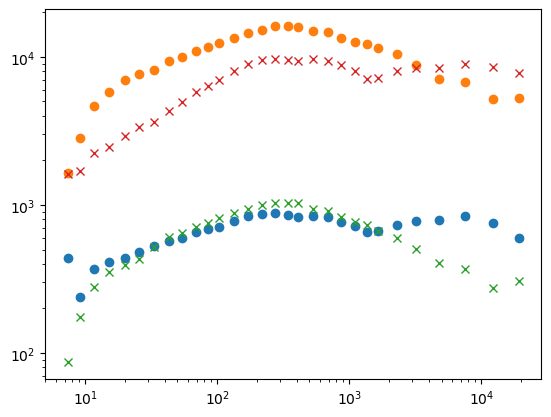

In [123]:
plt.loglog(tf_cls.period, rho_a[:, 0, 1], marker='o', linestyle="")
plt.loglog(tf_cls.period, rho_a[:, 1, 0], marker='o', linestyle="")
plt.loglog(tf_cls.period, rho_a[:, 0, 0], marker='x', linestyle="")
plt.loglog(tf_cls.period, rho_a[:, 1, 1], marker='x', linestyle="")

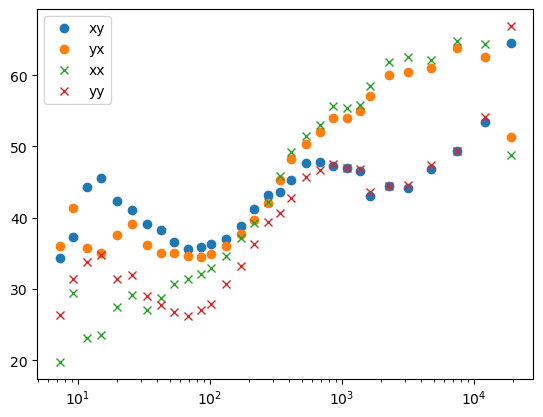

In [124]:
plt.semilogx(tf_cls.period, np.angle(Z[:, 0, 1], deg=True), marker='o', linestyle="", label='xy')
plt.semilogx(tf_cls.period, np.angle(Z[:, 1, 0], deg=True)+180, marker='o', linestyle="", label='yx')
plt.semilogx(tf_cls.period, np.angle(Z[:, 0, 0], deg=True)+180, marker='x', linestyle="", label='xx')
plt.semilogx(tf_cls.period, np.angle(Z[:, 1, 1], deg=True), marker='x', linestyle="", label='yy')
plt.legend()